# Custom Object Classification Project

Classes:
- Pens
- Bottles
- Notebooks
- Phones

Dataset Size:
- 25 images per class
- 100 images total

Objective:
Study how different machine learning concepts such as learning rate, optimizer choice, dropout, batch size, and optimization affect training behaviour and model performance.

In [60]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import random_split

###Dataset Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Verify Dataset Structure

In [ ]:
import os

root = "/content/drive/MyDrive"

for item in os.listdir(root):
    print(item)

1000538903.jpeg
Saved from the Google app
Untitled spreadsheet.gsheet
Report.gdoc
Project proposal.gdoc
Resume (1).gdoc
Resume.gdoc
Brochure.gdoc
Untitled document (2).gdoc
Essay (1).gdoc
Class notes.gdoc
Essay.gdoc
Untitled document - Line chart 1.gsheet
Untitled document - Pie chart 2.gsheet
Untitled document (1).gdoc
Untitled document.gdoc
Untitled form.gform
“T&C Decoder” Pre-Product Survey .gform
Colab Notebooks
project 


In [ ]:
import os

root = "/content/drive/MyDrive"

for item in os.listdir(root):
    print(repr(item))

'1000538903.jpeg'
'Saved from the Google app'
'Untitled spreadsheet.gsheet'
'Report.gdoc'
'Project proposal.gdoc'
'Resume (1).gdoc'
'Resume.gdoc'
'Brochure.gdoc'
'Untitled document (2).gdoc'
'Essay (1).gdoc'
'Class notes.gdoc'
'Essay.gdoc'
'Untitled document - Line chart 1.gsheet'
'Untitled document - Pie chart 2.gsheet'
'Untitled document (1).gdoc'
'Untitled document.gdoc'
'Untitled form.gform'
'“T&C Decoder” Pre-Product Survey .gform'
'Colab Notebooks'
'project '


In [ ]:
import os

project_path = "/content/drive/MyDrive/project "

print(os.listdir(project_path))

['pens', 'bottles', 'notebooks', 'phones']


In [ ]:
import os

project_path = "/content/drive/MyDrive/project "

for folder in os.listdir(project_path):
    folder_path = os.path.join(project_path, folder)

    first_file = os.listdir(folder_path)[0]

    full_path = os.path.join(folder_path, first_file)

    print("\n", full_path)
    print("Is file:", os.path.isfile(full_path))
    print("Is folder:", os.path.isdir(full_path))


 /content/drive/MyDrive/project /pens/Photo from Dr.Monica Nayak (24)
Is file: True
Is folder: False

 /content/drive/MyDrive/project /bottles/Photo from Dr.Monica Nayak (24)
Is file: True
Is folder: False

 /content/drive/MyDrive/project /notebooks/Photo from Dr.Monica Nayak (24)
Is file: True
Is folder: False

 /content/drive/MyDrive/project /phones/Photo from Dr.Monica Nayak (24)
Is file: True
Is folder: False


#### Image Extension Debugging

In [ ]:
import os

project_path = "/content/drive/MyDrive/project "

for class_folder in os.listdir(project_path):
    class_path = os.path.join(project_path, class_folder)

    for filename in os.listdir(class_path):

        old_path = os.path.join(class_path, filename)

        # Skip if already has an extension
        if "." not in filename:

            new_path = old_path + ".jpg"

            os.rename(old_path, new_path)

print("Done!")

Done!


In [ ]:
import os

project_path = "/content/drive/MyDrive/project "

folder = "pens"

for file in os.listdir(os.path.join(project_path, folder))[:5]:
    print(repr(file))

'Photo from Dr.Monica Nayak (24)'
'Photo from Dr.Monica Nayak (23)'
'Photo from Dr.Monica Nayak (22)'
'Photo from Dr.Monica Nayak (21)'
'Photo from Dr.Monica Nayak (20)'


In [ ]:
import os

project_path = "/content/drive/MyDrive/project "

folder = "pens"

file = os.listdir(os.path.join(project_path, folder))[0]

print("Name:", file)
print("Split:", file.split("."))
print("Contains dot:", "." in file)

Name: Photo from Dr.Monica Nayak (24)
Split: ['Photo from Dr', 'Monica Nayak (24)']
Contains dot: True


In [16]:
import os

project_path = "/content/drive/MyDrive/project "

folder = "pens"

file = os.listdir(os.path.join(project_path, folder))[0]

path = os.path.join(project_path, folder, file)

with open(path, "rb") as f:
    print(f.read(20))

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'


In [17]:
import os

project_path = "/content/drive/MyDrive/project "

for class_folder in os.listdir(project_path):
    class_path = os.path.join(project_path, class_folder)

    for filename in os.listdir(class_path):

        old_path = os.path.join(class_path, filename)

        # Add .jpg if it doesn't already end with .jpg/.jpeg/.png
        if not filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            new_path = old_path + ".jpg"

            os.rename(old_path, new_path)

print("Finished renaming files")

Finished renaming files


In [18]:
import os

project_path = "/content/drive/MyDrive/project "

for folder in os.listdir(project_path):
    folder_path = os.path.join(project_path, folder)

    print("\n", folder)

    print(os.listdir(folder_path)[:3])


 pens
['Photo from Dr.Monica Nayak (24).jpg', 'Photo from Dr.Monica Nayak (23).jpg', 'Photo from Dr.Monica Nayak (22).jpg']

 bottles
['Photo from Dr.Monica Nayak (24).jpg', 'Photo from Dr.Monica Nayak (23).jpg', 'Photo from Dr.Monica Nayak (22).jpg']

 notebooks
['Photo from Dr.Monica Nayak (24).jpg', 'Photo from Dr.Monica Nayak (23).jpg', 'Photo from Dr.Monica Nayak (22).jpg']

 phones
['Photo from Dr.Monica Nayak (24).jpg', 'Photo from Dr.Monica Nayak (23).jpg', 'Photo from Dr.Monica Nayak (22).jpg']


### Dataset Loading

In [19]:
from torchvision import datasets
from torchvision import transforms

dataset_path = "/content/drive/MyDrive/project "

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['bottles', 'notebooks', 'pens', 'phones']
Total Images: 100


### Train Validation Split

In [20]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Train Images: 80
Validation Images: 20


### Data Loaders

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 5
Validation batches: 2


### Baseline Neural Network

In [22]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64 * 64 * 3, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 4)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=4, bias=True)
)


In [23]:
criterion = nn.CrossEntropyLoss()

In [24]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

In [25]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

outputs = model(images)

print(outputs.shape)

torch.Size([16, 3, 64, 64])
torch.Size([16])
torch.Size([16, 4])


### Initial Training Run

In [27]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        predictions = model(images)

        loss = criterion(
            predictions,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}"
    )

Epoch 1/20, Loss: 0.6138
Epoch 2/20, Loss: 0.6348
Epoch 3/20, Loss: 0.9018
Epoch 4/20, Loss: 0.6177
Epoch 5/20, Loss: 0.5193
Epoch 6/20, Loss: 0.6987
Epoch 7/20, Loss: 0.5717
Epoch 8/20, Loss: 0.6344
Epoch 9/20, Loss: 0.6459
Epoch 10/20, Loss: 0.4845
Epoch 11/20, Loss: 0.5766
Epoch 12/20, Loss: 0.5821
Epoch 13/20, Loss: 0.5083
Epoch 14/20, Loss: 0.6227
Epoch 15/20, Loss: 0.6413
Epoch 16/20, Loss: 0.8732
Epoch 17/20, Loss: 0.7291
Epoch 18/20, Loss: 0.5753
Epoch 19/20, Loss: 0.6961
Epoch 20/20, Loss: 0.6062


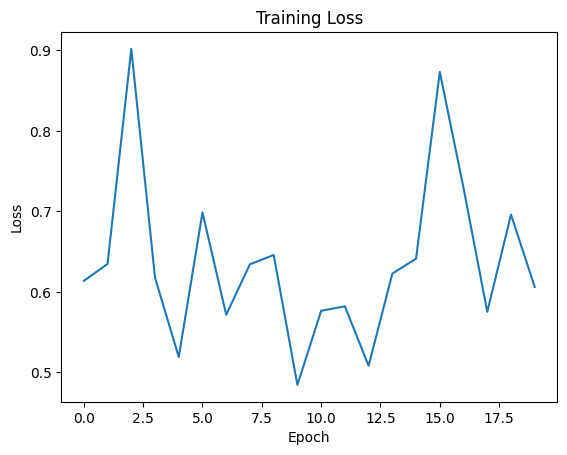

In [28]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

### Initial Validation Accuracy

In [29]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 40.00%


### Experiment 1: Learning Rate Comparison

Objective:
Compare the effect of different learning rates on training stability and validation accuracy.

Settings:
- Adam, lr = 0.01
- Adam, lr = 0.001

In [30]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64*64*3,128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,4)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [31]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        predictions = model(images)

        loss = criterion(predictions, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 3.4495
Epoch 2/20, Loss: 2.3435
Epoch 3/20, Loss: 1.5685
Epoch 4/20, Loss: 1.3183
Epoch 5/20, Loss: 1.0049
Epoch 6/20, Loss: 0.8741
Epoch 7/20, Loss: 0.7894
Epoch 8/20, Loss: 0.6561
Epoch 9/20, Loss: 0.6072
Epoch 10/20, Loss: 0.7681
Epoch 11/20, Loss: 0.6147
Epoch 12/20, Loss: 0.6885
Epoch 13/20, Loss: 0.5717
Epoch 14/20, Loss: 0.5820
Epoch 15/20, Loss: 0.7039
Epoch 16/20, Loss: 0.6137
Epoch 17/20, Loss: 0.5851
Epoch 18/20, Loss: 0.4853
Epoch 19/20, Loss: 0.4791
Epoch 20/20, Loss: 0.4689


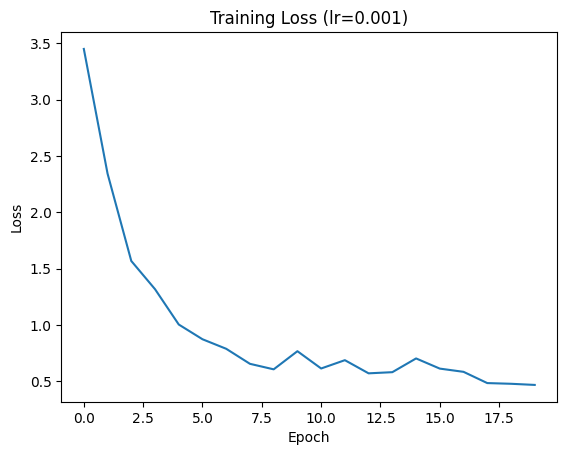

In [32]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (lr=0.001)")

plt.show()

In [33]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 45.00%


### Experiment 2: Optimizer Comparison

Objective:
Compare Adam and SGD optimizers while keeping other parameters fixed.

In [34]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64*64*3,128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,4)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

In [43]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        predictions = model(images)

        loss = criterion(predictions, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 1.3454
Epoch 2/20, Loss: 1.3326
Epoch 3/20, Loss: 1.3197
Epoch 4/20, Loss: 1.3096
Epoch 5/20, Loss: 1.2935
Epoch 6/20, Loss: 1.2883
Epoch 7/20, Loss: 1.2731
Epoch 8/20, Loss: 1.2671
Epoch 9/20, Loss: 1.2561
Epoch 10/20, Loss: 1.2501
Epoch 11/20, Loss: 1.2368
Epoch 12/20, Loss: 1.2253
Epoch 13/20, Loss: 1.2227
Epoch 14/20, Loss: 1.2090
Epoch 15/20, Loss: 1.1973
Epoch 16/20, Loss: 1.1898
Epoch 17/20, Loss: 1.1829
Epoch 18/20, Loss: 1.1745
Epoch 19/20, Loss: 1.1590
Epoch 20/20, Loss: 1.1512


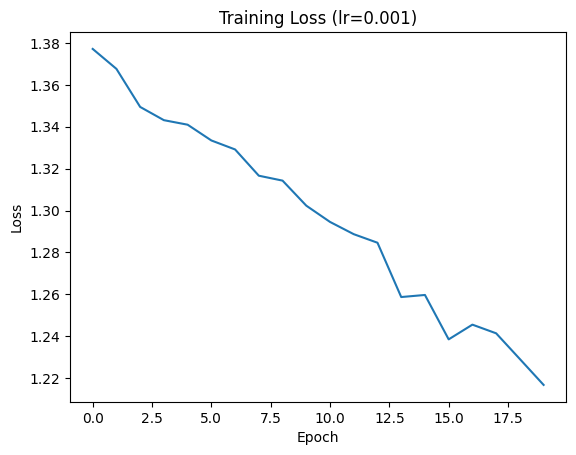

In [36]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (lr=0.001)")

plt.show()

In [37]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 50.00%


### Experiment 3: Dropout Comparison

Objective:
Study the effect of dropout regularization on model performance.

In [40]:

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64*64*3,128),
    nn.ReLU(),
    nn.Linear(128,4)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

In [44]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        predictions = model(images)

        loss = criterion(predictions, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 1.1432
Epoch 2/20, Loss: 1.1341
Epoch 3/20, Loss: 1.1239
Epoch 4/20, Loss: 1.1179
Epoch 5/20, Loss: 1.1119
Epoch 6/20, Loss: 1.1011
Epoch 7/20, Loss: 1.0953
Epoch 8/20, Loss: 1.0856
Epoch 9/20, Loss: 1.0764
Epoch 10/20, Loss: 1.0764
Epoch 11/20, Loss: 1.0624
Epoch 12/20, Loss: 1.0563
Epoch 13/20, Loss: 1.0517
Epoch 14/20, Loss: 1.0421
Epoch 15/20, Loss: 1.0330
Epoch 16/20, Loss: 1.0250
Epoch 17/20, Loss: 1.0170
Epoch 18/20, Loss: 1.0123
Epoch 19/20, Loss: 1.0060
Epoch 20/20, Loss: 0.9953


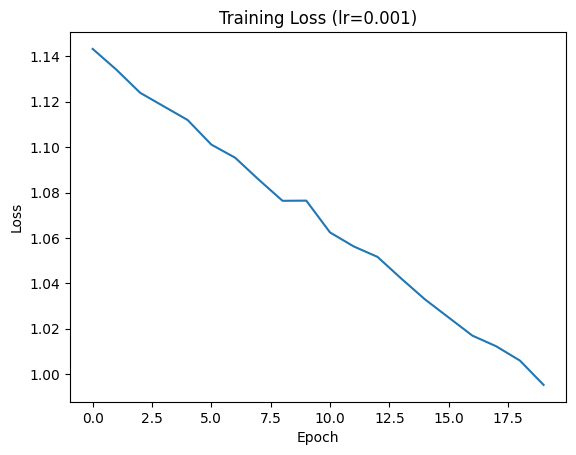

In [45]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (lr=0.001)")

plt.show()

In [46]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 50.00%


### Experiment 4: Batch Size Comparison

Objective:
Compare batch sizes 16 and 4 and observe changes in training behaviour.

In [48]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [50]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64*64*3,128),
    nn.ReLU(),
    nn.Linear(128,4)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

In [51]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        predictions = model(images)

        loss = criterion(predictions, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 1.4072
Epoch 2/20, Loss: 1.3507
Epoch 3/20, Loss: 1.3075
Epoch 4/20, Loss: 1.2858
Epoch 5/20, Loss: 1.2423
Epoch 6/20, Loss: 1.2025
Epoch 7/20, Loss: 1.1634
Epoch 8/20, Loss: 1.1417
Epoch 9/20, Loss: 1.0999
Epoch 10/20, Loss: 1.0836
Epoch 11/20, Loss: 1.0489
Epoch 12/20, Loss: 1.0290
Epoch 13/20, Loss: 1.0058
Epoch 14/20, Loss: 0.9776
Epoch 15/20, Loss: 0.9477
Epoch 16/20, Loss: 0.9251
Epoch 17/20, Loss: 0.9111
Epoch 18/20, Loss: 0.9012
Epoch 19/20, Loss: 0.8678
Epoch 20/20, Loss: 0.8534


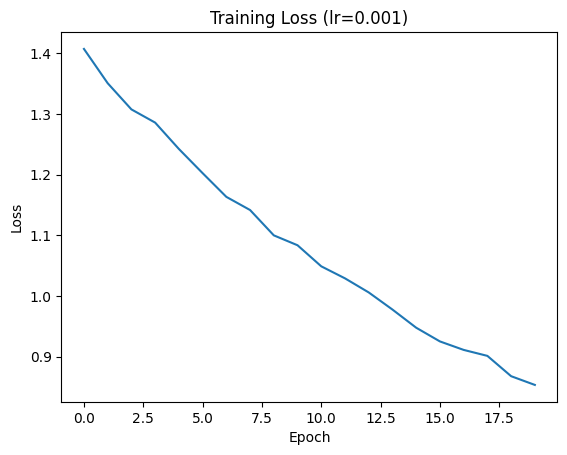

In [52]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (lr=0.001)")

plt.show()

In [53]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 35.00%


## Final Model Evaluation

In [54]:

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64*64*3,128),
    nn.ReLU(),
    nn.Linear(128,4)
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

In [55]:
num_epochs = 20

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_train_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()

    running_val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)

    accuracy = 100 * correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {accuracy:.2f}%"
    )

Epoch 1/20 | Train Loss: 1.4035 | Val Loss: 1.3716 | Val Acc: 15.00%
Epoch 2/20 | Train Loss: 1.3897 | Val Loss: 1.3638 | Val Acc: 20.00%
Epoch 3/20 | Train Loss: 1.3755 | Val Loss: 1.3556 | Val Acc: 30.00%
Epoch 4/20 | Train Loss: 1.3630 | Val Loss: 1.3511 | Val Acc: 35.00%
Epoch 5/20 | Train Loss: 1.3502 | Val Loss: 1.3441 | Val Acc: 35.00%
Epoch 6/20 | Train Loss: 1.3381 | Val Loss: 1.3403 | Val Acc: 35.00%
Epoch 7/20 | Train Loss: 1.3292 | Val Loss: 1.3310 | Val Acc: 35.00%
Epoch 8/20 | Train Loss: 1.3163 | Val Loss: 1.3303 | Val Acc: 35.00%
Epoch 9/20 | Train Loss: 1.3045 | Val Loss: 1.3267 | Val Acc: 35.00%
Epoch 10/20 | Train Loss: 1.2957 | Val Loss: 1.3205 | Val Acc: 35.00%
Epoch 11/20 | Train Loss: 1.2837 | Val Loss: 1.3159 | Val Acc: 40.00%
Epoch 12/20 | Train Loss: 1.2738 | Val Loss: 1.3130 | Val Acc: 45.00%
Epoch 13/20 | Train Loss: 1.2651 | Val Loss: 1.3066 | Val Acc: 40.00%
Epoch 14/20 | Train Loss: 1.2546 | Val Loss: 1.3049 | Val Acc: 45.00%
Epoch 15/20 | Train Loss: 1.2

#### Training Loss

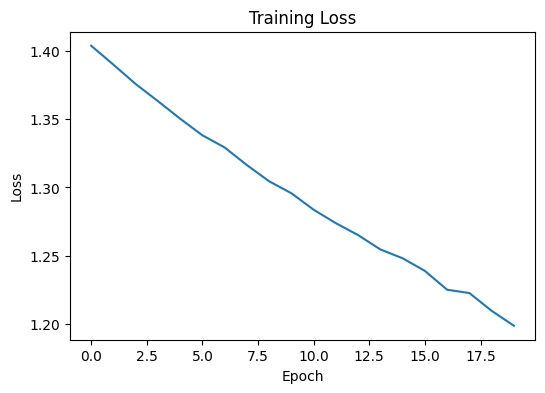

In [56]:
plt.figure(figsize=(6,4))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

#### Validation Loss

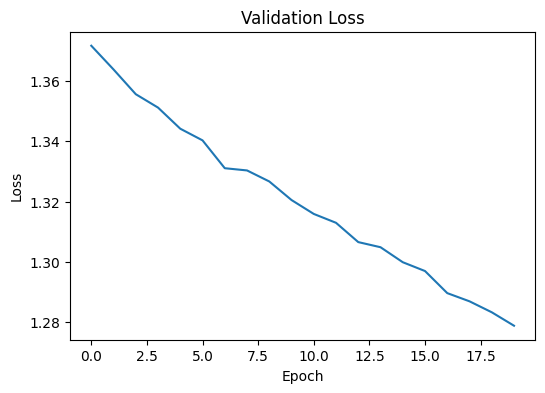

In [57]:
plt.figure(figsize=(6,4))

plt.plot(val_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")

plt.show()

#### Validation Accuracy

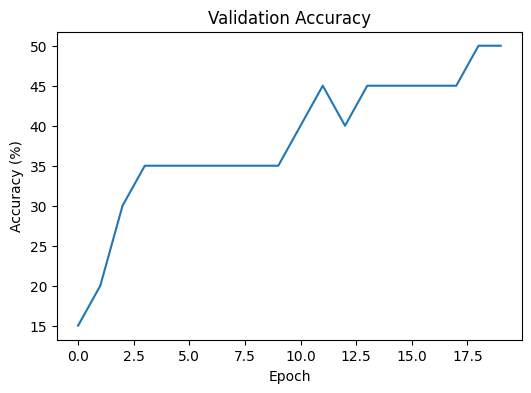

In [58]:
plt.figure(figsize=(6,4))

plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")

plt.show()

## Results Summary

| Experiment | Validation Accuracy |
|------------|---------------------|
| Adam (0.01) | 40% |
| Adam (0.001) | 45% |
| SGD (0.001) | 50% |
| No Dropout | 50% |
| Batch Size 4 | 35% |

## Observations

1. Lower learning rates resulted in smoother training behaviour.

2. SGD achieved the highest validation accuracy despite slower convergence.

3. Removing dropout had little effect on accuracy.

4. Smaller batch sizes produced lower training loss but worse validation accuracy.

5. High learning rates caused unstable training and oscillating loss values.